# Reward calibration for DDPO physics finetuning

**Goal.** Before finetuning the SR diffusion model with DDPO, establish that the four candidate
reward components are *reliable*: they must rank sample quality correctly, be sensitive in the
regime where our models actually live (hi-k ret ≈ 0.36, MSE ≈ 0.142), resist obvious reward
hacking, and keep stable scales across Re so one weighting works cross-regime.

**Components** (`src/rewards.py`, all reference-free w.r.t. paired GT — anchored to *regime
statistics* + the PDE itself, so they can drive finetuning toward regimes with no paired HR data):

| component | measures | anchored to |
|:--|:--|:--|
| `spec` | mean sq. log-ratio of enstrophy spectrum, shells 1–96 | regime mean spectrum |
| `spec_highk` | same, shells 32–96 (the deficit band) | regime mean spectrum |
| `energy` | sq. log-ratio of total enstrophy (energy conservation) | regime mean enstrophy |
| `w1` | Wasserstein-1 of pointwise vorticity PDF (quantiles) | regime mean quantiles |
| `pde` | mean NS residual² at the regime's Re (dynamics/phases) | the equation (GT floor ≠ 0) |
| `pde_lr` | sq. log-ratio of `pde` to the GT residual floor | "as consistent as the data itself" |

Spectral distances use the **geometric-mean** anchor (`log_spec_ref`): per-shell frame spectra are
~log-normal, so an arithmetic-mean anchor sits above the typical frame and slight blur can look
*better* than GT (first-pass finding). `pde_lr` exists because the raw residual of GT is dominated
by truncation noise that mild smoothing *removes* — raw `pde` therefore slightly rewards blurring,
while the log-ratio form penalizes leaving the GT floor in either direction.

**Calibration questions**
1. **Monotonicity** — does each distance grow monotonically along controlled degradation ladders
   (blur, spectral low-pass, noise, phase-scramble)?
2. **Sensitivity / SNR** — do the distances separate the *real* model outputs (base + 4 conditional,
   Re=1000 seqs 32–33) from GT and from each other, beyond per-frame noise?
3. **Hackability** — phase-scrambling preserves the spectrum *exactly*: which components are blind
   to it (hackable alone) and which catch it?
4. **Cross-Re stability** — GT floor and distance scales at Re=500/1000/2000 → per-Re normalization
   table for the combined reward.

**Output**: `base_results/regime_stats_re{500,1000,2000}.npz` + `base_results/reward_calibration.json`
(scales, GT floors, residual refs, recommended weights) consumed by `src.rewards.make_ddpo_reward`.

CPU-only (TPU may be busy with the inference queue); streams pkls one at a time; skips missing files.


In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")   # never touch the TPU (inference queue owns it)
os.chdir("/home/rhautier/ddpm-jax")
import sys; sys.path.insert(0, ".")
import pickle, json
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.stats import spearmanr

from src import rewards as R
from src.sequence_inference import sparse_nnfill_degrade

MEAN, STD, N, DT = 0.0, 4.7988, 256, 1.0 / 32.0
KMAX, KBAND, HIK = N // 2, (1, 96), (32, 96)
REC = "monitoring/sparse_reconstructions"
MODELS = ["base", "grad_frozen60", "grad_full60", "field_frozen60", "field_full60"]
MODEL_C = {m: c for m, c in zip(MODELS, ["#4269d0", "#efb118", "#ff725c", "#6cc5b0", "#9c6b4e"])}
GT_C, INPUT_C = "#222222", "#999999"
RE_CFG = {
    500:  dict(gt="flow-data/kf_re500_256_20seed.npy",       stat_seqs=range(8, 20), eval_seq=8),
    1000: dict(gt="flow-data/kf_2d_re1000_256_40seed.npy",   stat_seqs=range(0, 32, 4), eval_seq=36),
    2000: dict(gt="flow-data/kf_re2000_256_20seed.npy",      stat_seqs=range(8, 20), eval_seq=8),
}
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
                     "axes.axisbelow": True, "font.size": 9})
rng = np.random.default_rng(0)
GT = {re: np.load(c["gt"], mmap_mode="r") for re, c in RE_CFG.items() if os.path.exists(c["gt"])}
for re, a in GT.items(): print(f"Re={re}: GT {a.shape} ({a.dtype})")


Re=500: GT (20, 320, 256, 256) (float32)
Re=1000: GT (40, 320, 256, 256) (float32)
Re=2000: GT (20, 320, 256, 256) (float32)


## 1. Regime statistics (reward anchors) + GT residual floor

Anchors are computed from *training-side* sequences (Re=1000: train seqs; Re=500/2000: seqs 8–19,
disjoint from the OOD eval seqs 0–7), 160 frames each — the data a finetune run would legitimately
have access to. The PDE residual floor is the GT's own mean residual² (nonzero: finite differences
in time + spectral truncation), which is the *optimum* the reward should target, not 0.


In [2]:
def norm(x): return (np.asarray(x, np.float32) - MEAN) / STD

def gt_triplets(re, seq, t0s):
    seq_arr = GT[re][seq]
    return np.stack([np.stack([norm(seq_arr[t]), norm(seq_arr[t + 1]), norm(seq_arr[t + 2])], -1)
                     for t in t0s])

STATS, RES_REF, PDE_RAW = {}, {}, {}
for re, cfg in RE_CFG.items():
    if re not in GT: continue
    path = f"base_results/regime_stats_re{re}.npz"
    frames = np.stack([norm(GT[re][s, t]) for s in cfg["stat_seqs"] for t in range(60, 300, 12)])
    STATS[re] = R.compute_regime_stats(frames)
    R.save_regime_stats(STATS[re], path)
    pde_raw = R.make_pde_residual_distance(re=float(re), std=STD, mean=MEAN)
    PDE_RAW[re] = pde_raw
    floor_tris = np.concatenate([gt_triplets(re, s, range(100, 292, 24)) for s in list(cfg["stat_seqs"])[:4]])
    RES_REF[re] = float(np.mean(np.asarray(pde_raw(floor_tris))))
    print(f"Re={re}: {frames.shape[0]} stat frames | enstrophy_ref={STATS[re]['enstrophy_ref']:.4f} | "
          f"GT residual floor={RES_REF[re]:.2f} -> {path}")
del frames, floor_tris


Re=500: 240 stat frames | enstrophy_ref=0.8140 | GT residual floor=1.56 -> base_results/regime_stats_re500.npz


Re=1000: 160 stat frames | enstrophy_ref=0.9983 | GT residual floor=17.46 -> base_results/regime_stats_re1000.npz


Re=2000: 240 stat frames | enstrophy_ref=1.0157 | GT residual floor=45.99 -> base_results/regime_stats_re2000.npz


In [3]:
# distance fns per regime: pde in RAW mode + pde_lr anchored at the regime's GT residual floor
spectrum = R.make_spectrum_fn(N)
COMPS = {}
for re in STATS:
    lref = STATS[re]["log_spec_ref"]
    COMPS[re] = {
        "spec":       R.make_spectrum_distance(STATS[re]["spec_ref"], kband=KBAND, log_ref=lref),
        "spec_highk": R.make_spectrum_distance(STATS[re]["spec_ref"], kband=HIK, log_ref=lref),
        "energy":     R.make_energy_distance(STATS[re]["enstrophy_ref"]),
        "w1":         R.make_vorticity_w1_distance(STATS[re]["quantiles_ref"]),
        "pde":        PDE_RAW[re],
        "pde_lr":     R.make_pde_residual_distance(re=float(re), std=STD, mean=MEAN,
                                                   residual_ref=RES_REF[re]),
    }
CNAMES = ["spec", "spec_highk", "energy", "w1", "pde", "pde_lr"]
COMP_C = dict(zip(CNAMES, ["#4269d0", "#3ca951", "#efb118", "#ff725c", "#9498a0", "#a463f2"]))

def eval_comps(re, tris):
    return {k: np.asarray(f(tris)) for k, f in COMPS[re].items()}

def hik_ret(tris, gt_tris):
    e_r, e_g = np.asarray(spectrum(tris)), np.asarray(spectrum(gt_tris))
    return e_r[:, HIK[0]:].sum(-1) / e_g[:, HIK[0]:].sum(-1)


## 2. Degradation ladders (Re=1000, held-out test seq 36)

Controlled corruptions of GT triplets, each targeting a different failure mode:

- **blur** (σ): the over-smoothing pathology the base model actually has.
- **lowpass** (k_cut): idealized over-smoothing — energy removed above a sharp cutoff.
- **noise** (σₙ): spurious high-k energy (the NN-fill input pathology).
- **phase-scramble** (k₀): keep the spectrum *bit-exact*, randomize phases of shells ≥ k₀ (same
  scramble on all 3 frames — the temporally-coherent, hardest-to-catch variant). k₀=0 is
  "spectrum-matched noise": the canonical hack against purely spectral rewards.
- **nn-fill input**: the actual degraded model input, as a reference point.

A usable reward must be **monotone** along each ladder it claims to police, and the panel as a
whole must have no direction that improves every component while degrading the flow.


In [4]:
KR_GRID = None
def _kr():
    global KR_GRID
    if KR_GRID is None:
        k = np.fft.fftfreq(N, d=1.0 / N); KR_GRID = np.sqrt(k[:, None] ** 2 + k[None, :] ** 2)
    return KR_GRID

def d_blur(tris, s):    return gaussian_filter(tris, sigma=(0, s, s, 0))
def d_noise(tris, s):   return tris + s * rng.standard_normal(tris.shape).astype(np.float32)
def d_lowpass(tris, kc):
    keep = (_kr() <= kc)
    F = np.fft.fft2(tris, axes=(1, 2))
    return np.fft.ifft2(F * keep[None, :, :, None], axes=(1, 2)).real.astype(np.float32)
def d_scramble(tris, k0):
    m = (_kr() >= max(k0, 1e-9)) if k0 > 0 else np.ones_like(_kr(), bool)
    out = np.empty_like(tris)
    for i in range(len(tris)):
        ph = np.angle(np.fft.fft2(rng.standard_normal((N, N))))     # Hermitian random phases
        F = np.fft.fft2(tris[i], axes=(0, 1))
        newph = np.where(m[:, :, None], ph[:, :, None], np.angle(F))
        out[i] = np.fft.ifft2(np.abs(F) * np.exp(1j * newph), axes=(0, 1)).real
    return out

LADDERS = {
    "blur":     [("sigma", s, d_blur)    for s in [0.5, 0.75, 1.0, 2.0, 4.0]],
    "lowpass":  [("k_cut", k, d_lowpass) for k in [96, 64, 48, 32, 24, 16, 8]],
    "noise":    [("sigma_n", s, d_noise) for s in [0.02, 0.05, 0.1, 0.25, 0.5]],
    "scramble": [("k0", k, d_scramble)   for k in [64, 32, 16, 8, 4, 0]],
}
EVAL_RE, EVAL_SEQ = 1000, RE_CFG[1000]["eval_seq"]
T0S = range(100, 164, 8)                                            # 8 triplets
gt_tris = gt_triplets(EVAL_RE, EVAL_SEQ, T0S)
raw_seq = np.asarray(GT[EVAL_RE][EVAL_SEQ, 99:166], np.float32)     # covers T0S+2 with margin
nn_seq = norm(sparse_nnfill_degrade(raw_seq, EVAL_SEQ))
nn_tris = np.stack([np.stack([nn_seq[t - 99], nn_seq[t - 98], nn_seq[t - 97]], -1) for t in T0S])

ladder_res = {"GT": {"level": None, **{k: v for k, v in eval_comps(EVAL_RE, gt_tris).items()}},
              "nnfill_input": {"level": None, **eval_comps(EVAL_RE, nn_tris)}}
for fam, levels in LADDERS.items():
    for pname, lv, fn in levels:
        ladder_res[f"{fam} {pname}={lv:g}"] = {"family": fam, "level": lv,
                                               **eval_comps(EVAL_RE, fn(gt_tris, lv))}
print(f"{'condition':<22}" + "".join(f"{c:>12}" for c in CNAMES))
for name, r in ladder_res.items():
    print(f"{name:<22}" + "".join(f"{np.mean(r[c]):>12.4g}" for c in CNAMES))


condition                     spec  spec_highk      energy          w1         pde      pde_lr
GT                          0.3482      0.4362     0.02956      0.1066       25.24      0.1744
nnfill_input                 5.688       8.327     0.03678      0.1098   1.556e+04       45.94
blur sigma=0.5              0.0967     0.07683     0.02629      0.1038          18     0.05235
blur sigma=0.75             0.6698      0.9436     0.02202      0.1004       15.14     0.04879
blur sigma=1                 1.864       2.724     0.01796     0.09724       16.81     0.03029
blur sigma=2                 4.974       7.041    0.006441     0.09043       37.45      0.6056
blur sigma=4                 6.166       5.647     0.03126      0.1069       79.01       2.174
lowpass k_cut=96            0.3482      0.4362     0.02954      0.1066       25.96       0.191
lowpass k_cut=64             62.45       92.62     0.02924      0.1063       33.94      0.4587
lowpass k_cut=48             94.53       140.2    

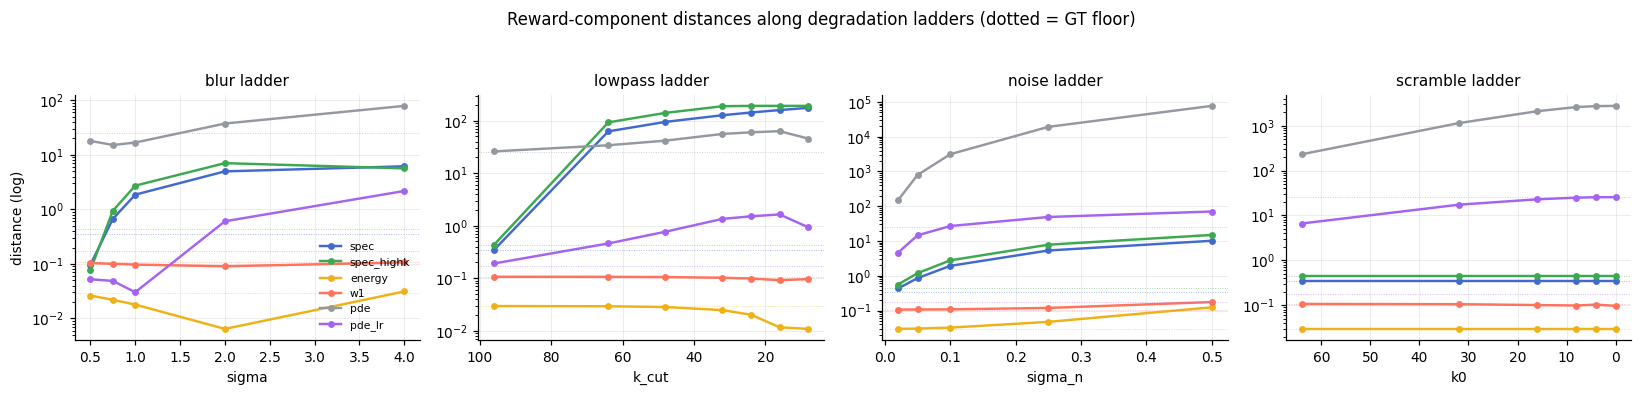

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for ax, (fam, levels) in zip(axes, LADDERS.items()):
    xs = [lv for _, lv, _ in levels]
    for c in CNAMES:
        ys = [np.mean(ladder_res[f"{fam} {levels[0][0]}={lv:g}"][c]) for lv in xs]
        ax.plot(xs, ys, "o-", ms=3.5, lw=1.6, label=c, color=COMP_C[c])
        ax.axhline(np.mean(ladder_res["GT"][c]), color=COMP_C[c], lw=0.6, ls=":", alpha=0.5)
    ax.set_yscale("log"); ax.set_title(f"{fam} ladder", fontsize=10)
    ax.set_xlabel(levels[0][0])
    if fam in ("lowpass", "scramble"): ax.invert_xaxis()   # stronger degradation to the right
axes[0].set_ylabel("distance (log)"); axes[0].legend(fontsize=7, frameon=False)
fig.suptitle("Reward-component distances along degradation ladders (dotted = GT floor)", y=1.04)
plt.tight_layout(); plt.show()


In [6]:
# Monotonicity verdicts: Spearman rho of mean distance vs degradation strength, per family.
# lowpass/scramble strength grows as the cutoff SHRINKS -> negate level there.
print(f"{'family':<10}" + "".join(f"{c:>12}" for c in CNAMES) + "   (Spearman rho vs strength)")
mono = {}
for fam, levels in LADDERS.items():
    strength = [-lv if fam in ("lowpass", "scramble") else lv for _, lv, _ in levels]
    row = {}
    for c in CNAMES:
        ys = [np.mean(ladder_res[f"{fam} {levels[0][0]}={lv:g}"][c]) for _, lv, _ in levels]
        row[c] = spearmanr(strength, ys).statistic
    mono[fam] = row
    print(f"{fam:<10}" + "".join(f"{row[c]:>12.2f}" for c in CNAMES))
print("\n|rho| >= 0.9 = monotone. Expected blind spots: spec/spec_highk/energy/w1 on 'scramble'")
print("(spectrum preserved bit-exact) -- that is the hack the PDE component must catch.")
scr = {c: np.mean(ladder_res["scramble k0=0"][c]) / max(np.mean(ladder_res["GT"][c]), 1e-12) for c in CNAMES}
print("\nspectrum-matched noise (scramble k0=0), distance / GT floor:")
print("   " + "  ".join(f"{c}: {scr[c]:.2f}x" for c in CNAMES))


family            spec  spec_highk      energy          w1         pde      pde_lr   (Spearman rho vs strength)
blur              1.00        0.90        0.00        0.00        0.70        0.60
lowpass           1.00        0.96       -1.00       -0.96        0.79        0.79
noise             1.00        1.00        1.00        1.00        1.00        1.00
scramble          0.49        0.34        0.23       -0.83        1.00        1.00

|rho| >= 0.9 = monotone. Expected blind spots: spec/spec_highk/energy/w1 on 'scramble'
(spectrum preserved bit-exact) -- that is the hack the PDE component must catch.

spectrum-matched noise (scramble k0=0), distance / GT floor:
   spec: 1.00x  spec_highk: 1.00x  energy: 1.00x  w1: 0.90x  pde: 109.52x  pde_lr: 146.35x


## 3. Separation on real model outputs (Re=1000 in-dist, seqs 32–33)

The models all sit in a narrow quality band (MSE 0.141–0.144, hi-k ret 0.35–0.37) — a reward that
can't resolve *this* band can't steer DDPO once training starts. Per frame (every 4th) we compute
all components + the pkl's stored MSE + hi-k retention vs GT, one pkl in memory at a time.


In [7]:
FRAME_STRIDE, SEQS = 4, [32, 33]
recs = {m: {c: [] for c in CNAMES + ["mse", "hik"]} for m in MODELS}
gt_cache = {}
for s in SEQS:
    t0s = range(0, 318, FRAME_STRIDE)
    gt_cache[s] = gt_triplets(1000, s, t0s)
for m in MODELS:
    for s in SEQS:
        p = f"{REC}/sequence_reconstruction_indist_re1000_{m}_seq{s}.pkl"
        if not os.path.exists(p): print(f"skip missing {p}"); continue
        with open(p, "rb") as f: res = pickle.load(f)
        frames = res["frames"][::FRAME_STRIDE]
        tris = np.stack([fr["final"] for fr in frames]).astype(np.float32)
        cc = eval_comps(1000, tris)
        for c in CNAMES: recs[m][c].append(cc[c])
        recs[m]["mse"].append(np.array([fr["mse"] for fr in frames]))
        recs[m]["hik"].append(hik_ret(tris, gt_cache[s][: len(tris)]))
        del res, tris, frames
    recs[m] = {k: np.concatenate(v) for k, v in recs[m].items() if v}
gt_all = np.concatenate([gt_cache[s] for s in SEQS])
gt_comps = eval_comps(1000, gt_all)
print(f"{'model':<16}" + "".join(f"{c:>12}" for c in CNAMES) + f"{'mse':>10}{'hik_ret':>10}")
print(f"{'GT':<16}" + "".join(f"{np.mean(gt_comps[c]):>12.4g}" for c in CNAMES) + f"{'—':>10}{'1.00':>10}")
for m in MODELS:
    if not recs[m]: continue
    print(f"{m:<16}" + "".join(f"{np.mean(recs[m][c]):>12.4g}" for c in CNAMES)
          + f"{np.mean(recs[m]['mse']):>10.4f}{np.mean(recs[m]['hik']):>10.3f}")
del gt_all, gt_cache


model                   spec  spec_highk      energy          w1         pde      pde_lr       mse   hik_ret
GT                    0.4737      0.5822     0.01242     0.06422       13.45       3.135         —      1.00
base                   1.107       1.389      0.0335     0.07825       30.08      0.3649    0.1389     0.484
grad_frozen60          1.125       1.415     0.03242     0.07775        28.5      0.3175    0.1388     0.482
grad_full60            1.183       1.491     0.03173     0.07767       31.82      0.4048    0.1370     0.466
field_frozen60         1.105       1.387     0.03192     0.07747       30.48      0.3739    0.1389     0.485
field_full60           1.202        1.51     0.03214     0.07766       28.97      0.3122    0.1363     0.450


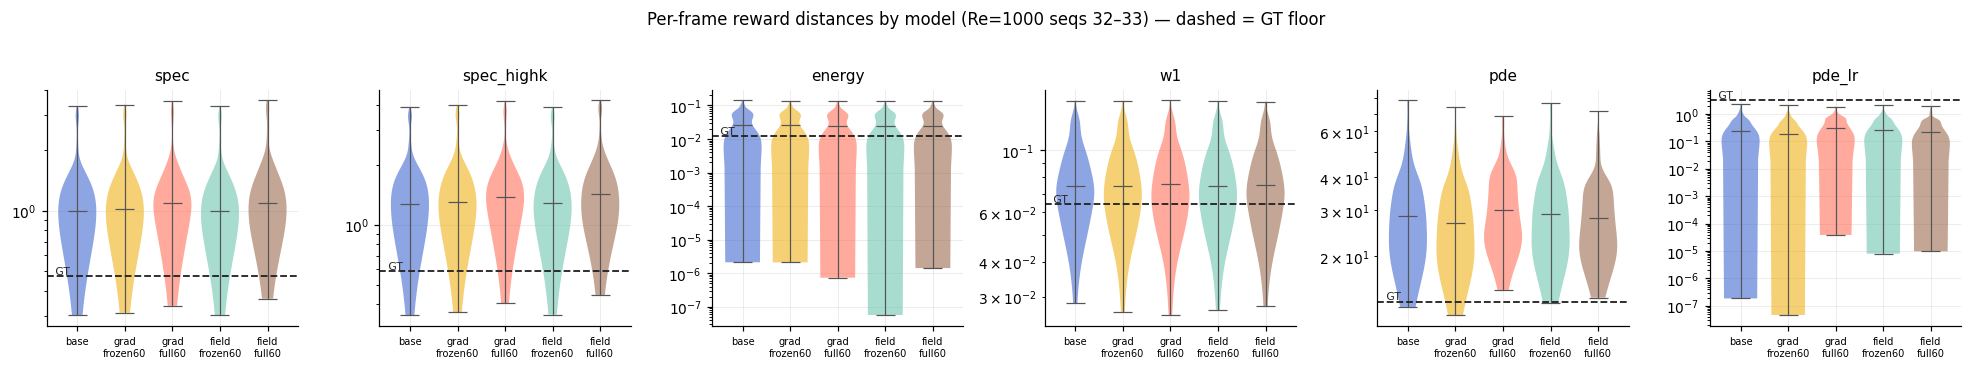

In [8]:
fig, axes = plt.subplots(1, len(CNAMES), figsize=(18, 3.2))
for ax, c in zip(axes, CNAMES):
    data = [recs[m][c] for m in MODELS if recs[m]]
    parts = ax.violinplot(data, showmedians=True, widths=0.8)
    for pc, m in zip(parts["bodies"], [m for m in MODELS if recs[m]]):
        pc.set_facecolor(MODEL_C[m]); pc.set_alpha(0.6)
    for k in ("cmedians", "cmins", "cmaxes", "cbars"): parts[k].set_color("#555555"); parts[k].set_linewidth(0.8)
    ax.axhline(np.mean(gt_comps[c]), color=GT_C, lw=1.2, ls="--")
    ax.text(0.02, np.mean(gt_comps[c]), " GT", va="bottom", fontsize=7, color=GT_C,
            transform=ax.get_yaxis_transform())
    ax.set_title(c, fontsize=10); ax.set_yscale("log")
    ax.set_xticks(range(1, len(data) + 1))
    ax.set_xticklabels([m.replace("_", "\n") for m in MODELS if recs[m]], fontsize=6.5)
fig.suptitle("Per-frame reward distances by model (Re=1000 seqs 32–33) — dashed = GT floor", y=1.03)
plt.tight_layout(); plt.show()


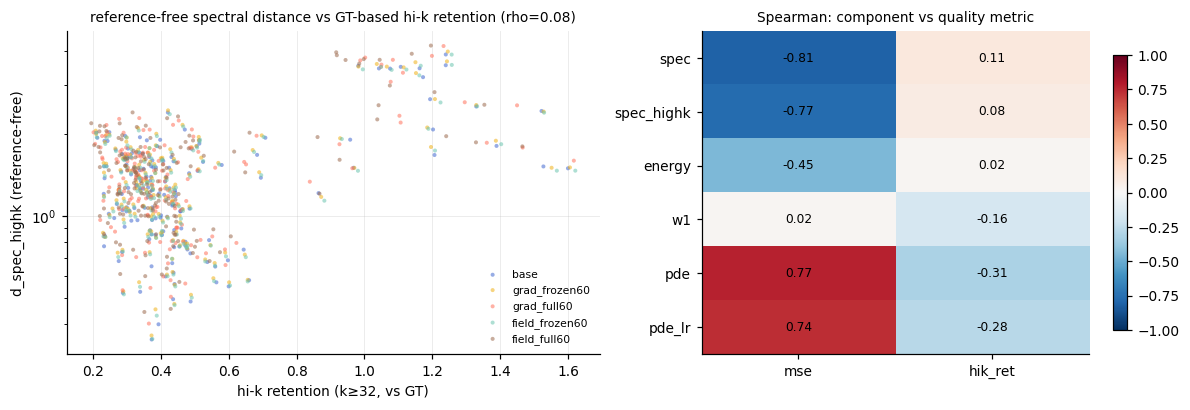

In [9]:
# Does the spectral reward measure the thing we want to fix? d_spec_highk vs hi-k retention,
# and full Spearman matrix of components vs the two quality metrics.
pool = {k: np.concatenate([recs[m][k] for m in MODELS if recs[m]]) for k in CNAMES + ["mse", "hik"]}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.8), gridspec_kw={"width_ratios": [1.1, 1]})
for m in MODELS:
    if recs[m]: a1.scatter(recs[m]["hik"], recs[m]["spec_highk"], s=7, alpha=0.55,
                           color=MODEL_C[m], label=m, edgecolors="none")
a1.set_xlabel("hi-k retention (k≥32, vs GT)"); a1.set_ylabel("d_spec_highk (reference-free)")
a1.set_yscale("log"); a1.legend(fontsize=7, frameon=False)
rho = spearmanr(pool["hik"], pool["spec_highk"]).statistic
a1.set_title(f"reference-free spectral distance vs GT-based hi-k retention (rho={rho:.2f})", fontsize=9)
M = np.array([[spearmanr(pool[c], pool[t]).statistic for t in ["mse", "hik"]] for c in CNAMES])
im = a2.imshow(M, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
a2.set_xticks([0, 1]); a2.set_xticklabels(["mse", "hik_ret"]); a2.set_yticks(range(len(CNAMES)))
a2.set_yticklabels(CNAMES); a2.grid(False)
for i in range(len(CNAMES)):
    for j in range(2): a2.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=a2, shrink=0.85); a2.set_title("Spearman: component vs quality metric", fontsize=9)
plt.tight_layout(); plt.show()


In [10]:
# The DDPO-relevant correlation. Per-frame pooled rho is diluted by anchor variance: each
# frame's own GT deviates from the regime anchor, adding a per-INPUT offset to every distance.
# DDPO computes advantages per input (several samples of the same input), so that offset cancels.
# Proxy here: the 5 models are 5 'samples' of the SAME input -> rank-correlate distance vs
# hi-k retention WITHIN each frame across models, then average over frames. Also report the
# model-level rank correlation of the 5 (mean distance, mean hik) pairs.
ms = [m for m in MODELS if recs[m]]
nfr = min(len(recs[m]["hik"]) for m in ms)
print(f"{'component':<12}{'pooled per-frame rho':>22}{'within-input rho':>18}{'model-level rho':>18}")
for c in CNAMES:
    pooled = spearmanr(pool[c], pool["hik"]).statistic
    D = np.stack([recs[m][c][:nfr] for m in ms]); H = np.stack([recs[m]["hik"][:nfr] for m in ms])
    within = np.nanmean([spearmanr(D[:, i], H[:, i]).statistic for i in range(nfr)])
    mlevel = spearmanr([np.mean(recs[m][c]) for m in ms],
                       [np.mean(recs[m]["hik"]) for m in ms]).statistic
    print(f"{c:<12}{pooled:>22.2f}{within:>18.2f}{mlevel:>18.2f}")
print("\n(negative = distance falls as hi-k retention improves, i.e. the reward points the right way)")


component     pooled per-frame rho  within-input rho   model-level rho
spec                          0.11             -0.74             -1.00
spec_highk                    0.08             -0.70             -1.00
energy                        0.02              0.12              0.20
w1                           -0.16              0.06              0.00


pde                          -0.31             -0.02              0.20
pde_lr                       -0.28              0.07              0.40

(negative = distance falls as hi-k retention improves, i.e. the reward points the right way)


In [11]:
# SNR: can the reward tell the five models apart beyond per-frame noise?
print(f"{'component':<12}{'between-model std':>20}{'within-model std':>20}{'SNR':>8}")
snr = {}
for c in CNAMES:
    means = [np.mean(recs[m][c]) for m in MODELS if recs[m]]
    within = np.mean([np.std(recs[m][c]) for m in MODELS if recs[m]])
    snr[c] = np.std(means) / max(within, 1e-12)
    print(f"{c:<12}{np.std(means):>20.4g}{within:>20.4g}{snr[c]:>8.3f}")
print("\nNote: these five models are nearly indistinguishable BY CONSTRUCTION (same base, same")
print("task, MSE within 2%). Low between-model SNR here is expected; what matters for DDPO is")
print("the per-frame spread WITHIN a model (the advantage signal) and the model-vs-GT gap, which")
print("the violins show is orders of magnitude for spec/spec_highk.")


component      between-model std    within-model std     SNR
spec                     0.04038              0.5765   0.070
spec_highk               0.05195              0.6825   0.076
energy                 0.0006209             0.03178   0.020
w1                     0.0002618             0.02436   0.011
pde                        1.174               11.09   0.106
pde_lr                   0.03514              0.3884   0.090

Note: these five models are nearly indistinguishable BY CONSTRUCTION (same base, same
task, MSE within 2%). Low between-model SNR here is expected; what matters for DDPO is
the per-frame spread WITHIN a model (the advantage signal) and the model-vs-GT gap, which
the violins show is orders of magnitude for spec/spec_highk.


## 4. Cross-Re stability + calibration output

For each regime: GT floor per component (distance of held-out GT against its own regime anchors —
the irreducible noise of the anchor estimate), plus the distance scale of an actual recon
population (OOD base recons at Re=500/2000 seq 0; in-dist pool at Re=1000). The **scale** written
to the json is the per-component std over the recon population — the population DDPO sees at step
0 — so `reward = -Σ wᵢ dᵢ/sᵢ` starts with comparable component magnitudes at every Re.


In [12]:
OOD_PKL = {500: f"{REC}/sequence_reconstruction_ood_re500_base_seq0.pkl",
           2000: f"{REC}/sequence_reconstruction_ood_re2000_base_seq0.pkl"}
calib = {}
for re in sorted(STATS):
    floor_tris = gt_triplets(re, RE_CFG[re]["eval_seq"], range(100, 260, 8))
    floor = eval_comps(re, floor_tris)
    if re == 1000:
        recon_comps = {c: pool[c] for c in CNAMES}
    elif os.path.exists(OOD_PKL[re]):
        with open(OOD_PKL[re], "rb") as f: res = pickle.load(f)
        tris = np.stack([fr["final"] for fr in res["frames"][::FRAME_STRIDE]]).astype(np.float32)
        recon_comps = eval_comps(re, tris); del res, tris
    else:
        print(f"skip Re={re}: no recon pkl"); recon_comps = None
    calib[re] = {
        "residual_ref": RES_REF[re],
        "gt_floor": {c: float(np.mean(floor[c])) for c in CNAMES},
        "recon_mean": {c: float(np.mean(recon_comps[c])) for c in CNAMES} if recon_comps else None,
        "scales": {c: float(np.std(recon_comps[c])) for c in CNAMES} if recon_comps else None,
        "stats_path": f"base_results/regime_stats_re{re}.npz",
    }
for c in CNAMES:
    print(f"\n{c}:")
    print(f"{'Re':>6}{'GT floor':>14}{'recon mean':>14}{'scale (std)':>14}{'recon/floor':>13}")
    for re in sorted(calib):
        cl = calib[re]
        rm = cl["recon_mean"][c] if cl["recon_mean"] else float("nan")
        sc = cl["scales"][c] if cl["scales"] else float("nan")
        print(f"{re:>6}{cl['gt_floor'][c]:>14.4g}{rm:>14.4g}{sc:>14.4g}{rm / max(cl['gt_floor'][c], 1e-12):>13.1f}")



spec:
    Re      GT floor    recon mean   scale (std)  recon/floor
   500       0.07595        0.8848        0.1637         11.6
  1000        0.2018         1.144        0.5782          5.7
  2000       0.06639         4.098        0.7008         61.7

spec_highk:
    Re      GT floor    recon mean   scale (std)  recon/floor
   500       0.08587          1.22        0.2738         14.2
  1000        0.2436         1.439        0.6848          5.9
  2000       0.05906          5.72        0.9762         96.9

energy:
    Re      GT floor    recon mean   scale (std)  recon/floor
   500       0.01856       0.09317       0.05302          5.0
  1000       0.01758       0.03234       0.03179          1.8
  2000      0.004166        0.1773       0.08024         42.6

w1:
    Re      GT floor    recon mean   scale (std)  recon/floor
   500       0.05329        0.1035       0.04241          1.9
  1000       0.09235       0.07776       0.02436          0.8
  2000       0.07316        0.1448  

In [13]:
# Recommended starting configuration for DDPO (weights in SCALED units; revise after first runs):
#  - spec_highk carries the objective (the hi-k deficit is the thing to fix)
#  - spec keeps the rest of the cascade anchored while high-k energy is being added
#  - pde is the anti-hack term (only component that sees phases/dynamics)
#  - energy + w1 are cheap guards against gross drift, small weights
WEIGHTS = {"spec": 0.5, "spec_highk": 1.0, "energy": 0.25, "w1": 0.25, "pde": 1.0}
out = {"weights": WEIGHTS, "pde_mode": "logratio", "kband": list(KBAND), "highk_band": list(HIK),
       "std": STD, "mean": MEAN, "regimes": {str(re): calib[re] for re in calib},
       "note": "scales = std of each distance over the step-0 recon population at that Re. "
               "Run make_ddpo_reward with residual_ref=regimes[re]['residual_ref'] (logratio "
               "pde: the GT floor is the optimum, not 0) and use scales['pde_lr'] as the pde "
               "scale in that mode. Spectral anchors are geometric-mean (log_spec_ref in the "
               "regime npz)."}
with open("base_results/reward_calibration.json", "w") as f:
    json.dump(out, f, indent=2)
print("wrote base_results/reward_calibration.json")
print(json.dumps(WEIGHTS, indent=2))


wrote base_results/reward_calibration.json
{
  "spec": 0.5,
  "spec_highk": 1.0,
  "energy": 0.25,
  "w1": 0.25,
  "pde": 1.0
}


## 5. Verdicts

Computed, not hand-written. Each component is judged **only on the ladders it claims to police**
(total-energy and PDF distances are scale-redistribution-blind *by design* — that's what the
spectral terms are for):

| component | polices | blind to (by design / accepted) |
|:--|:--|:--|
| `spec`, `spec_highk` | blur, lowpass, noise | phases (scramble) |
| `energy` | noise, gross energy drift | scale redistribution, phases |
| `w1` | noise, PDF-tail clipping | phases, mild blur |
| `pde_lr` | scramble, noise | (small-σ blur ambiguity absorbed by per-input baseline) |

Criteria: **monotone** = |Spearman| ≥ 0.9 on each policed ladder · **separates** = Re=1000 recon
mean ≥ 3× GT floor · **hack check** = distance under spectrum-matched noise (scramble k₀=0) vs GT
floor · **within-input rho** = the advantage-relevant correlation with hi-k retention.


In [14]:
POLICED = {"spec": ["blur", "lowpass", "noise"], "spec_highk": ["blur", "lowpass", "noise"],
           "energy": ["noise"], "w1": ["noise"], "pde": ["scramble", "noise"],
           "pde_lr": ["scramble", "noise"]}
print(f"{'component':<12}{'monotone (policed ladders)':>28}{'scramble/GTfloor':>18}"
      f"{'recon/GTfloor':>15}{'within-input rho':>18}")
for c in CNAMES:
    ok = all(abs(mono[f][c]) >= 0.9 for f in POLICED[c])
    sep = calib[1000]["recon_mean"][c] / max(calib[1000]["gt_floor"][c], 1e-12)
    D = np.stack([recs[m][c][:nfr] for m in ms]); H = np.stack([recs[m]["hik"][:nfr] for m in ms])
    within = np.nanmean([spearmanr(D[:, i], H[:, i]).statistic for i in range(nfr)])
    print(f"{c:<12}{('PASS' if ok else 'FAIL'):>28}{scr[c]:>17.1f}x{sep:>14.1f}x{within:>18.2f}")
print()
print("Composition logic: spec/spec_highk measure exactly the hi-k deficit but are phase-blind ->")
print("pde_lr is the complementary dynamics check (the ONLY component that fires on spectrum-")
print("matched noise). energy/w1 are cheap guards against gross drift. A sample can only win the")
print("combined reward by adding energy at the right scales AND keeping NS-consistent dynamics.")


component     monotone (policed ladders)  scramble/GTfloor  recon/GTfloor  within-input rho
spec                                PASS              1.0x           5.7x             -0.74
spec_highk                          FAIL              1.0x           5.9x             -0.70


energy                              PASS              1.0x           1.8x              0.12
w1                                  PASS              0.9x           0.8x              0.06
pde                                 PASS            109.5x           1.5x             -0.02


pde_lr                              PASS            146.4x           2.2x              0.07



Composition logic: spec/spec_highk measure exactly the hi-k deficit but are phase-blind ->
pde_lr is the complementary dynamics check (the ONLY component that fires on spectrum-
matched noise). energy/w1 are cheap guards against gross drift. A sample can only win the
combined reward by adding energy at the right scales AND keeping NS-consistent dynamics.
